✅ Model 0 (baseline): 50 époques chargées
✅ Model 1 (+ dropout): 5 époques chargées
✅ Model 2 (+ augment): 10 époques chargées
✅ Model 3 (+ régul): 25 époques chargées
✅ YOLOv8n (pretrained): 100 époques chargées


/tmp/ipykernel_27581/1067087445.py:133: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1067087445.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1067087445.py:133: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1067087445.py:133: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1067087445.py:134: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1067087445.py:134: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1067087445.

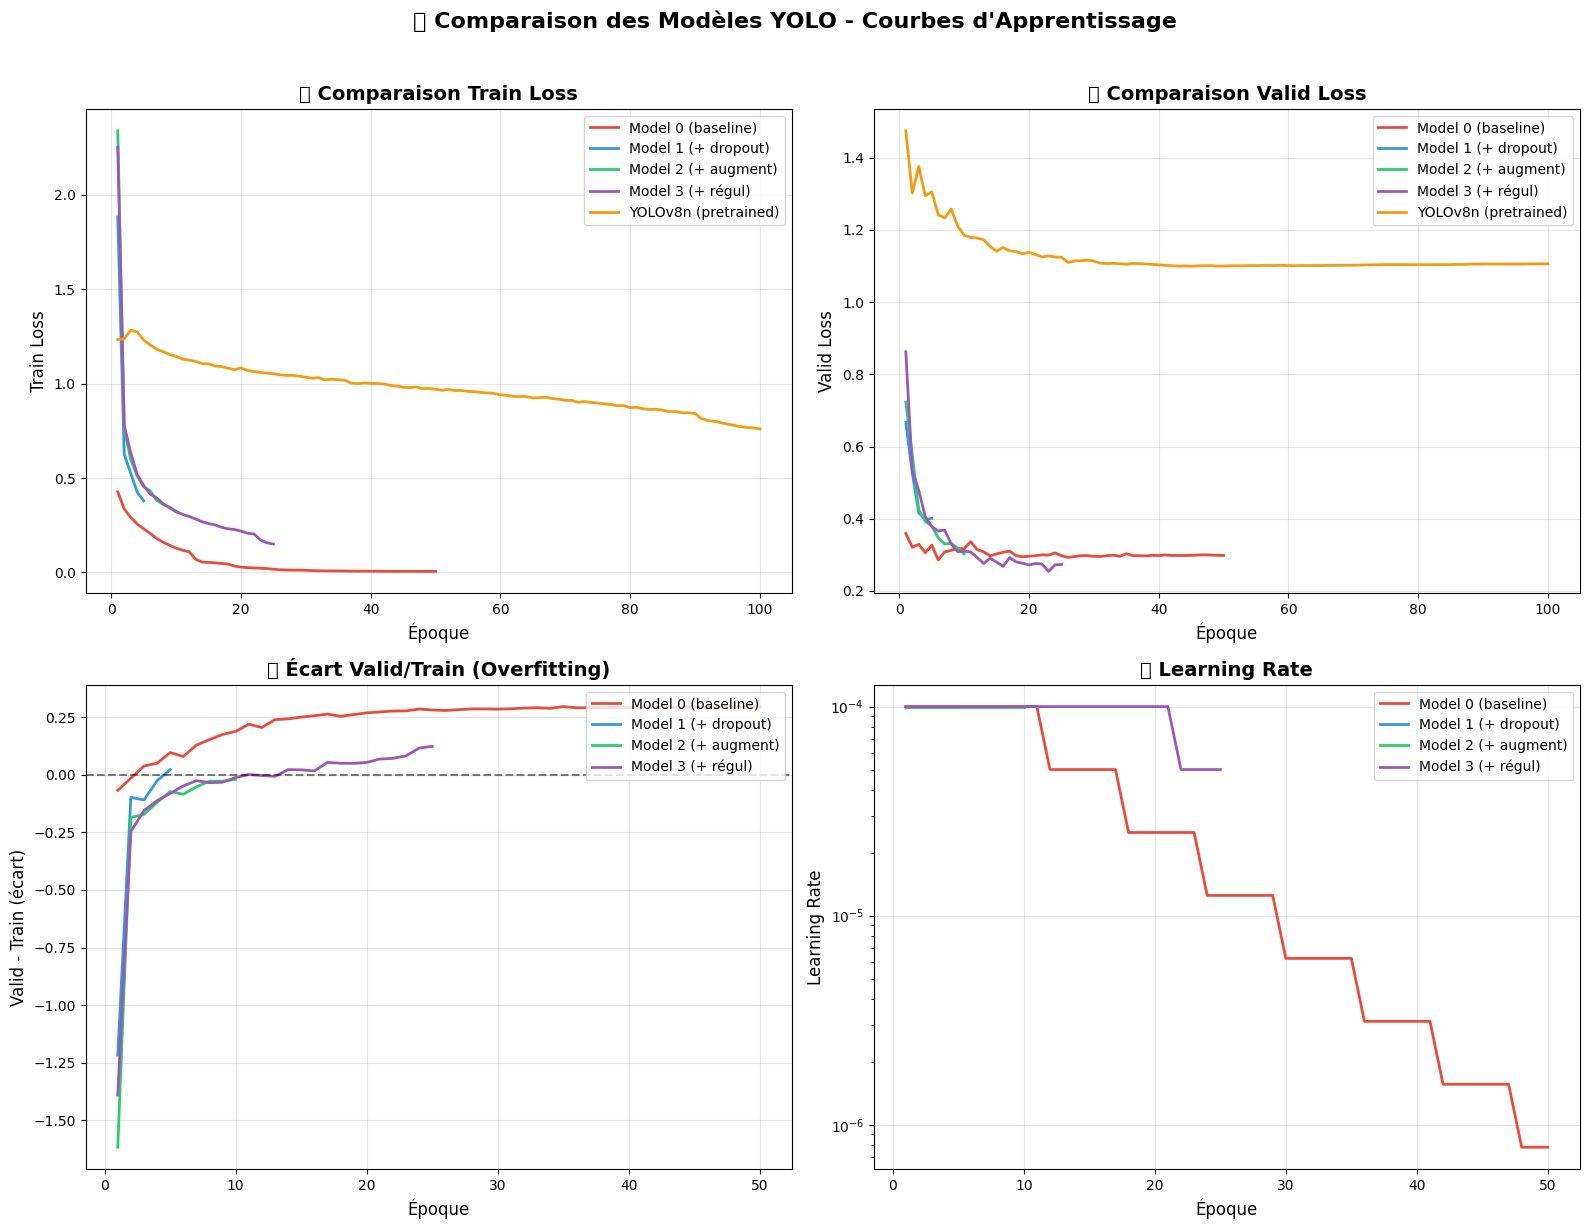


📊 TABLEAU RÉCAPITULATIF
             Modèle  Best Epoch Best Valid Loss Final Train Final Valid Écart (overfit)
 Model 0 (baseline)           6          0.2858      0.0050      0.2984          0.2934
Model 1 (+ dropout)           4          0.3984      0.3787      0.4009          0.0221
Model 2 (+ augment)          10          0.3024      0.3221      0.3024         -0.0197
  Model 3 (+ régul)          23          0.2541      0.1499      0.2732          0.1233


In [ ]:
# ============================================================
# Comparaison des courbes d'apprentissage - 5 Modèles
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Chemins vers les fichiers history.csv de chaque modèle
# À ADAPTER selon ton arborescence
histories = {
    'Model 0 (baseline)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_0/checkpoints/history.csv',
    'Model 1 (+ dropout)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_1/checkpoints/history.csv',
    'Model 2 (+ augment)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_2/checkpoints/history.csv',
    'Model 3 (+ régul)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_3/checkpoints/history.csv',
    'YOLOv8n (pretrained)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/runs/detect/LP_roboflow/results.csv',  # Format différent pour YOLOv8
}

# Couleurs distinctes pour chaque modèle
colors = {
    'Model 0 (baseline)': '#e74c3c',    # Rouge
    'Model 1 (+ dropout)': '#3498db',    # Bleu
    'Model 2 (+ augment)': '#2ecc71',    # Vert
    'Model 3 (+ régul)': '#9b59b6',      # Violet
    'YOLOv8n (pretrained)': '#f39c12',   # Orange
}

# ============================================================
# Charger les données
# ============================================================

data = {}
for name, path in histories.items():
    try:
        df = pd.read_csv(path)
        data[name] = df
        print(f"✅ {name}: {len(df)} époques chargées")
    except FileNotFoundError:
        print(f"❌ {name}: fichier non trouvé ({path})")

# ============================================================
# Graphique 1 : Train Loss comparée
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Train Loss ---
ax1 = axes[0, 0]
for name, df in data.items():
    if 'train' in df.columns:
        col = 'train'
    elif 'train_loss' in df.columns:
        col = 'train_loss'
    elif 'train/box_loss' in df.columns:  # YOLOv8 format
        col = 'train/box_loss'
    else:
        continue
    
    epochs = range(1, len(df) + 1)
    ax1.plot(epochs, df[col], label=name, color=colors[name], linewidth=2)

ax1.set_xlabel('Époque', fontsize=12)
ax1.set_ylabel('Train Loss', fontsize=12)
ax1.set_title('📉 Comparaison Train Loss', fontsize=14, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# --- Valid Loss ---
ax2 = axes[0, 1]
for name, df in data.items():
    if 'valid' in df.columns:
        col = 'valid'
    elif 'valid_loss' in df.columns:
        col = 'valid_loss'
    elif 'val/box_loss' in df.columns:  # YOLOv8 format
        col = 'val/box_loss'
    else:
        continue
    
    epochs = range(1, len(df) + 1)
    ax2.plot(epochs, df[col], label=name, color=colors[name], linewidth=2)

ax2.set_xlabel('Époque', fontsize=12)
ax2.set_ylabel('Valid Loss', fontsize=12)
ax2.set_title('📉 Comparaison Valid Loss', fontsize=14, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# --- Train vs Valid (écart = overfitting) ---
ax3 = axes[1, 0]
for name, df in data.items():
    # Identifier les colonnes
    if 'train' in df.columns and 'valid' in df.columns:
        train_col, valid_col = 'train', 'valid'
    elif 'train_loss' in df.columns and 'valid_loss' in df.columns:
        train_col, valid_col = 'train_loss', 'valid_loss'
    else:
        continue
    
    epochs = range(1, len(df) + 1)
    gap = df[valid_col] - df[train_col]  # Écart = overfitting
    ax3.plot(epochs, gap, label=name, color=colors[name], linewidth=2)

ax3.axhline(0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('Époque', fontsize=12)
ax3.set_ylabel('Valid - Train (écart)', fontsize=12)
ax3.set_title('📊 Écart Valid/Train (Overfitting)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper right')
ax3.grid(True, alpha=0.3)

# --- Learning Rate ---
ax4 = axes[1, 1]
for name, df in data.items():
    if 'lr' in df.columns:
        col = 'lr'
    elif 'learning_rate' in df.columns:
        col = 'learning_rate'
    else:
        continue
    
    epochs = range(1, len(df) + 1)
    ax4.plot(epochs, df[col], label=name, color=colors[name], linewidth=2)

ax4.set_xlabel('Époque', fontsize=12)
ax4.set_ylabel('Learning Rate', fontsize=12)
ax4.set_title('📈 Learning Rate', fontsize=14, fontweight='bold')
ax4.set_yscale('log')
ax4.legend(loc='upper right')
ax4.grid(True, alpha=0.3)

plt.suptitle('🏆 Comparaison des Modèles YOLO - Courbes d\'Apprentissage', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Tableau récapitulatif
# ============================================================

print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF")
print("="*70)

summary = []
for name, df in data.items():
    # Trouver les colonnes
    if 'train' in df.columns:
        train_col, valid_col = 'train', 'valid'
    elif 'train_loss' in df.columns:
        train_col, valid_col = 'train_loss', 'valid_loss'
    else:
        continue
    
    best_epoch = df[valid_col].idxmin() + 1
    best_valid = df[valid_col].min()
    final_train = df[train_col].iloc[-1]
    final_valid = df[valid_col].iloc[-1]
    gap = final_valid - final_train
    
    summary.append({
        'Modèle': name,
        'Best Epoch': best_epoch,
        'Best Valid Loss': f"{best_valid:.4f}",
        'Final Train': f"{final_train:.4f}",
        'Final Valid': f"{final_valid:.4f}",
        'Écart (overfit)': f"{gap:.4f}"
    })

df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))
print("="*70)
#```

### Instructions

# 1. **Adapte les chemins** dans le dictionnaire `histories` selon ton arborescence
# 2. **Vérifie les noms de colonnes** dans tes CSV (train/valid ou train_loss/valid_loss)
# 3. **Exécute** dans une cellule du notebook

#

In [5]:
# Afficher les colonnes du CSV YOLOv8
df_yolo = pd.read_csv('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/runs/detect/LP_roboflow/results.csv')
print(df_yolo.columns.tolist())
print(df_yolo.head())

['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2', 'lr/pg3', 'lr/pg4', 'lr/pg5', 'lr/pg6', 'lr/pg7']
   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   341.259         1.23353         1.46745         1.20651   
1      2   619.049         1.23686         0.80797         1.22106   
2      3   872.328         1.28294         0.80016         1.27075   
3      4  1127.450         1.27437         0.77158         1.28149   
4      5  1383.070         1.23054         0.70522         1.26134   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.94284            0.91288           0.95120   
1               0.95374            0.91557           0.95370   
2               0.93725            0.86585           0.93000   
3               0.95410            

Erreur YOLOv8n (pretrained): 'train_loss'


/tmp/ipykernel_27581/2826814971.py:59: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/2826814971.py:60: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_from_scratch.png', dpi=150, bbox_inches='tight')
/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


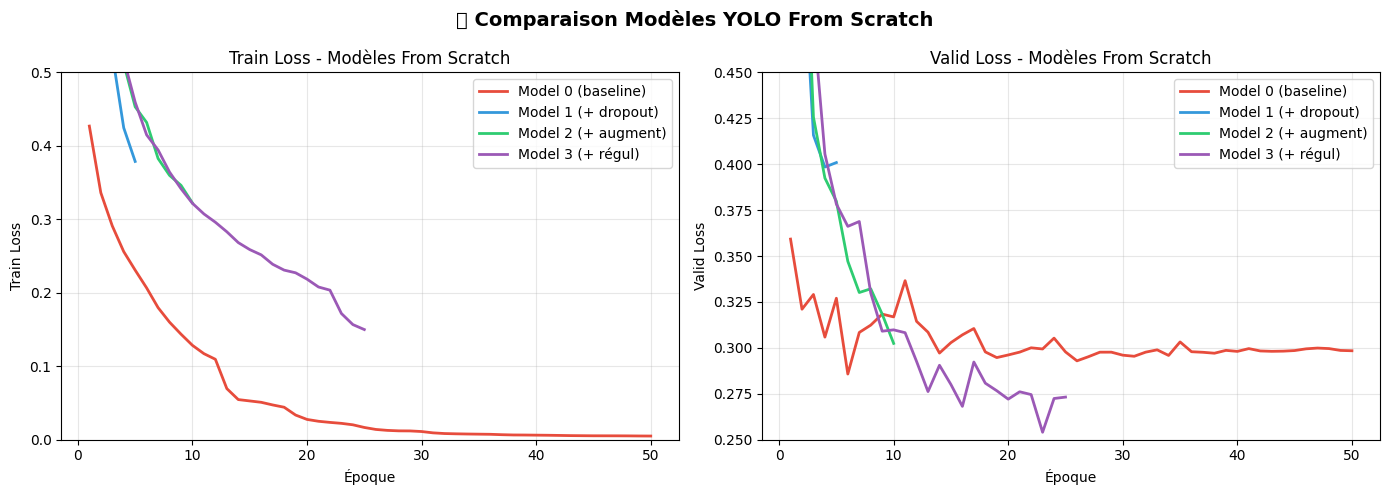

/tmp/ipykernel_27581/2826814971.py:121: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/2826814971.py:122: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('barplot_comparaison.png', dpi=150, bbox_inches='tight')



📊 COMPARAISON DES PERFORMANCES FINALES
             Modèle  Époques Train Loss (fin) Valid Loss (fin) Valid Loss (min)  Best Epoch Écart (overfit)
 Model 0 (baseline)       50           0.0050           0.2984           0.2858           6          0.2934
Model 1 (+ dropout)        5           0.3787           0.4009           0.3984           4          0.0221
Model 2 (+ augment)       10           0.3221           0.3024           0.3024          10         -0.0197
  Model 3 (+ régul)       25           0.1499           0.2732           0.2541          23          0.1233


/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


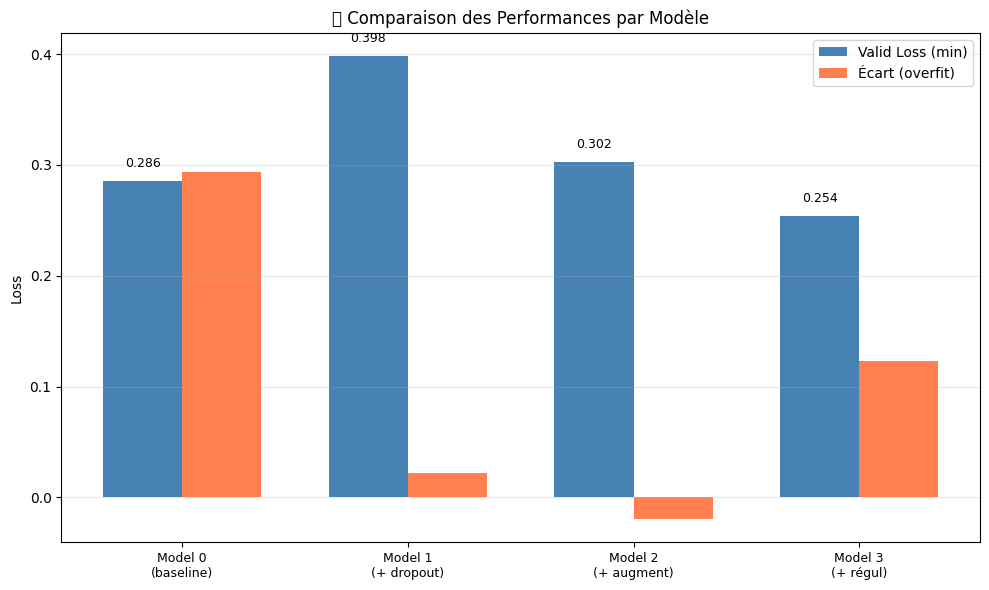

In [4]:
# ============================================================
# Comparaison des courbes - VERSION AMÉLIORÉE
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Charger les données (adapter les chemins)
# histories = {
#     'Model 0 (baseline)': 'Model_0/checkpoints/history.csv',
#     'Model 1 (+ dropout)': 'Model_1/checkpoints/history.csv',
#     'Model 2 (+ augment)': 'Model_2/checkpoints/history.csv',
#     'Model 3 (+ régul)': 'Model_3/checkpoints/history.csv',
# }

# YOLOv8 séparé (échelle différente)
yolov8_path = 'YOLOv8n/results.csv'

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# ============================================================
# GRAPHIQUE 1 : Modèles From Scratch uniquement
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Charger les modèles from scratch
for i, (name, path) in enumerate(histories.items()):
    try:
        df = pd.read_csv(path)
        epochs = range(1, len(df) + 1)
        
        # Train Loss
        train_col = 'train' if 'train' in df.columns else 'train_loss'
        valid_col = 'valid' if 'valid' in df.columns else 'valid_loss'
        
        axes[0].plot(epochs, df[train_col], label=name, color=colors[i], linewidth=2, linestyle='-')
        axes[1].plot(epochs, df[valid_col], label=name, color=colors[i], linewidth=2, linestyle='-')
        
    except Exception as e:
        print(f"Erreur {name}: {e}")

axes[0].set_xlabel('Époque')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Train Loss - Modèles From Scratch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 0.5)  # Limiter l'axe Y pour mieux voir

axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Valid Loss')
axes[1].set_title('Valid Loss - Modèles From Scratch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.25, 0.45)  # Zoom sur la zone intéressante

plt.suptitle('🔬 Comparaison Modèles YOLO From Scratch', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_from_scratch.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# GRAPHIQUE 2 : Tableau comparatif des métriques finales
# ============================================================

print("\n" + "="*80)
print("📊 COMPARAISON DES PERFORMANCES FINALES")
print("="*80)

results = []
for name, path in histories.items():
    try:
        df = pd.read_csv(path)
        train_col = 'train' if 'train' in df.columns else 'train_loss'
        valid_col = 'valid' if 'valid' in df.columns else 'valid_loss'
        
        results.append({
            'Modèle': name,
            'Époques': len(df),
            'Train Loss (fin)': f"{df[train_col].iloc[-1]:.4f}",
            'Valid Loss (fin)': f"{df[valid_col].iloc[-1]:.4f}",
            'Valid Loss (min)': f"{df[valid_col].min():.4f}",
            'Best Epoch': df[valid_col].idxmin() + 1,
            'Écart (overfit)': f"{df[valid_col].iloc[-1] - df[train_col].iloc[-1]:.4f}"
        })
    except:
        pass

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# ============================================================
# GRAPHIQUE 3 : Barplot des Valid Loss minimales
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

model_names = [r['Modèle'] for r in results]
valid_losses = [float(r['Valid Loss (min)']) for r in results]
ecarts = [float(r['Écart (overfit)']) for r in results]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, valid_losses, width, label='Valid Loss (min)', color='steelblue')
bars2 = ax.bar(x + width/2, ecarts, width, label='Écart (overfit)', color='coral')

ax.set_ylabel('Loss')
ax.set_title('🏆 Comparaison des Performances par Modèle')
ax.set_xticks(x)
ax.set_xticklabels([n.replace(' (', '\n(') for n in model_names], fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars1, valid_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('barplot_comparaison.png', dpi=150, bbox_inches='tight')
plt.show()

📊 Métriques chargées:
  Model 0 (baseline): P=86.23%, R=89.60%, F1=0.8788
  Model 1 (+ dropout): P=81.69%, R=78.34%, F1=0.7998
  Model 2 (+ augment): P=77.01%, R=81.49%, F1=0.7918
  Model 3 (+ régul): P=89.41%, R=90.27%, F1=0.8984
  YOLOv8n (pretrained): P=98.19%, R=96.56%, F1=0.9736


/tmp/ipykernel_27581/3391067411.py:71: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/3391067411.py:72: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_metrics_finale.png', dpi=150, bbox_inches='tight')
/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


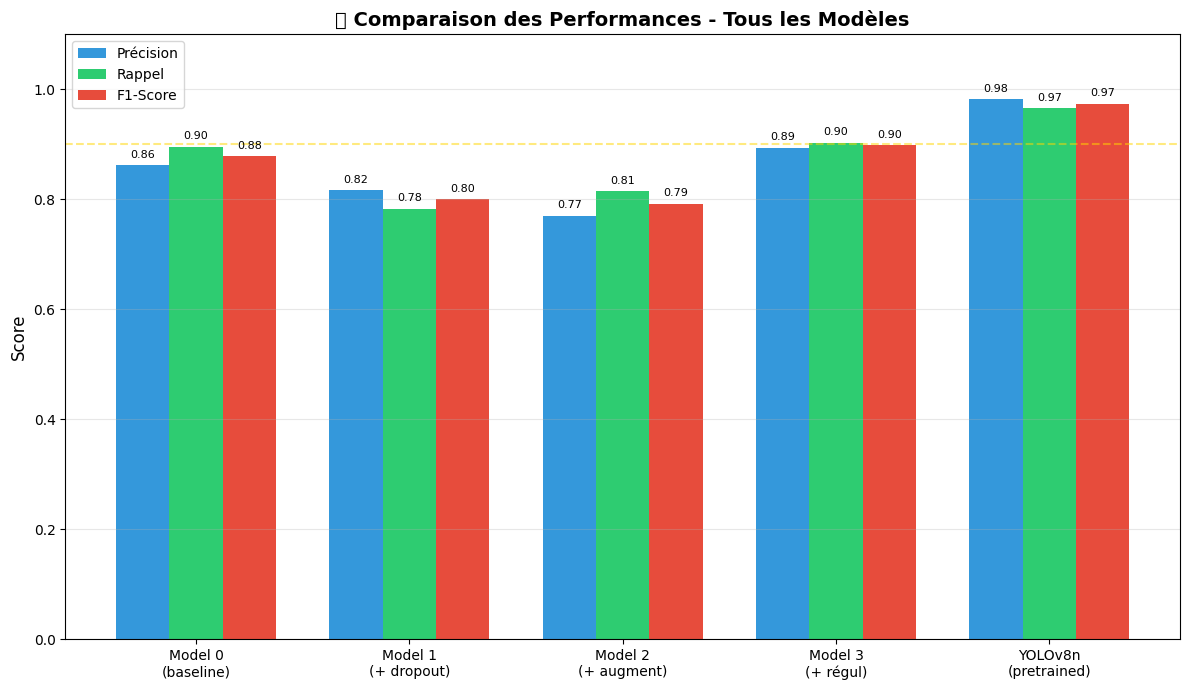

/tmp/ipykernel_27581/3391067411.py:104: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/3391067411.py:104: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/3391067411.py:105: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('yolov8_metrics.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/3391067411.py:105: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.savefig('yolov8_metrics.png', dpi=150, bbox_inches='tight')
/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/alpr_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES

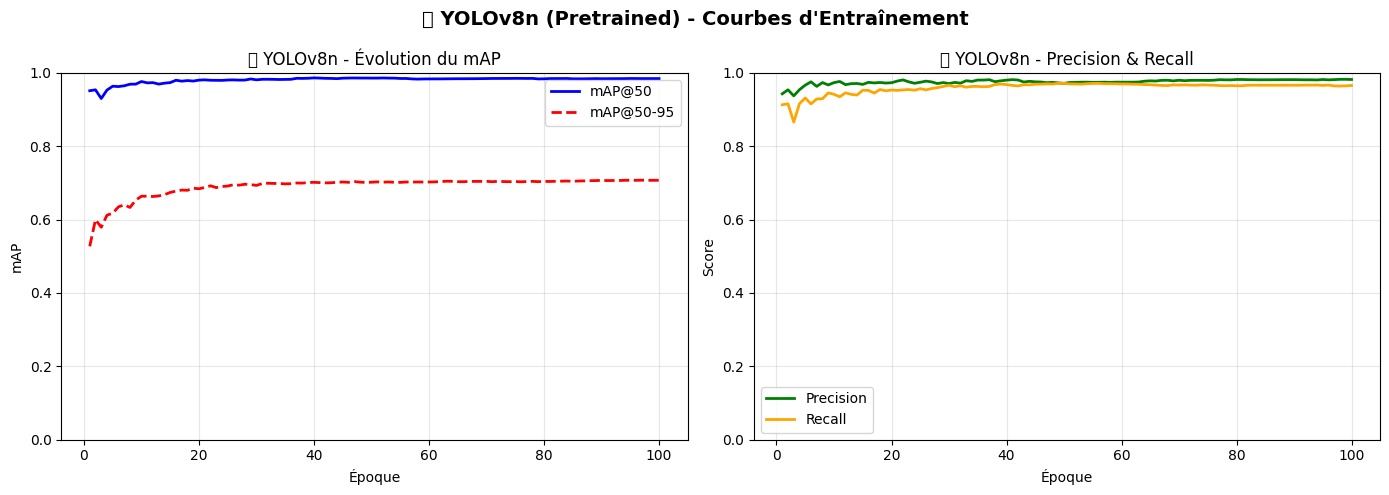


📊 TABLEAU RÉCAPITULATIF FINAL
                       Precision  Recall      F1
Modèle                                          
Model 0\n(baseline)       0.8623  0.8960  0.8788
Model 1\n(+ dropout)      0.8169  0.7834  0.7998
Model 2\n(+ augment)      0.7701  0.8149  0.7918
Model 3\n(+ régul)        0.8941  0.9027  0.8984
YOLOv8n\n(pretrained)     0.9819  0.9656  0.9736

🏆 MEILLEUR MODÈLE: YOLOv8n (pretrained)


In [6]:
# ============================================================
# Comparaison FINALE - Métriques comparables
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Charger les résultats de chaque modèle
# ============================================================

# Métriques finales de tes modèles From Scratch (à adapter avec tes vraies valeurs)
# Tu les as obtenues avec la fonction evaluate() sur le test set

results = {
    'Model 0\n(baseline)': {'Precision': 0.8623, 'Recall': 0.8960, 'F1': 0.8788},
    'Model 1\n(+ dropout)': {'Precision': 0.8169, 'Recall': 0.7834, 'F1': 0.7998}, 
    'Model 2\n(+ augment)': {'Precision': 0.7701, 'Recall': 0.8149, 'F1': 0.7918},  
    'Model 3\n(+ régul)': {'Precision': 0.8941, 'Recall': 0.9027, 'F1': 0.8984},    
}

# Charger les métriques YOLOv8 (dernière époque)
df_yolo = pd.read_csv('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/runs/detect/LP_roboflow/results.csv')  
results['YOLOv8n\n(pretrained)'] = {
    'Precision': df_yolo['metrics/precision(B)'].iloc[-1],
    'Recall': df_yolo['metrics/recall(B)'].iloc[-1],
    'F1': 2 * df_yolo['metrics/precision(B)'].iloc[-1] * df_yolo['metrics/recall(B)'].iloc[-1] / 
          (df_yolo['metrics/precision(B)'].iloc[-1] + df_yolo['metrics/recall(B)'].iloc[-1])
}

print("📊 Métriques chargées:")
for name, metrics in results.items():
    print(f"  {name.replace(chr(10), ' ')}: P={metrics['Precision']:.2%}, R={metrics['Recall']:.2%}, F1={metrics['F1']:.4f}")

# ============================================================
# 2. Barplot comparatif
# ============================================================

fig, ax = plt.subplots(figsize=(12, 7))

models = list(results.keys())
x = np.arange(len(models))
width = 0.25

precision = [results[m]['Precision'] for m in models]
recall = [results[m]['Recall'] for m in models]
f1 = [results[m]['F1'] for m in models]

bars1 = ax.bar(x - width, precision, width, label='Précision', color='#3498db')
bars2 = ax.bar(x, recall, width, label='Rappel', color='#2ecc71')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#e74c3c')

# Ajouter les valeurs sur les barres
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('🏆 Comparaison des Performances - Tous les Modèles', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(0.9, color='gold', linestyle='--', alpha=0.5, label='Seuil 90%')

plt.tight_layout()
plt.savefig('comparaison_metrics_finale.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. Courbe mAP50 de YOLOv8 au cours de l'entraînement
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = df_yolo['epoch'].values

# mAP50
axes[0].plot(epochs, df_yolo['metrics/mAP50(B)'], 'b-', linewidth=2, label='mAP@50')
axes[0].plot(epochs, df_yolo['metrics/mAP50-95(B)'], 'r--', linewidth=2, label='mAP@50-95')
axes[0].set_xlabel('Époque')
axes[0].set_ylabel('mAP')
axes[0].set_title('📈 YOLOv8n - Évolution du mAP')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 1)

# Precision & Recall
axes[1].plot(epochs, df_yolo['metrics/precision(B)'], 'g-', linewidth=2, label='Precision')
axes[1].plot(epochs, df_yolo['metrics/recall(B)'], 'orange', linewidth=2, label='Recall')
axes[1].set_xlabel('Époque')
axes[1].set_ylabel('Score')
axes[1].set_title('📈 YOLOv8n - Precision & Recall')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.suptitle('🚀 YOLOv8n (Pretrained) - Courbes d\'Entraînement', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('yolov8_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 4. Tableau récapitulatif final
# ============================================================

print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF FINAL")
print("="*70)

df_summary = pd.DataFrame(results).T
df_summary.index.name = 'Modèle'
df_summary = df_summary.round(4)
print(df_summary.to_string())

print("\n🏆 MEILLEUR MODÈLE:", df_summary['F1'].idxmax().replace('\n', ' '))
print("="*70)

/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:125: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_27581/1965474505.py:126: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
/mnt/c/DEV/JEDHA/FULLSTACK_WS

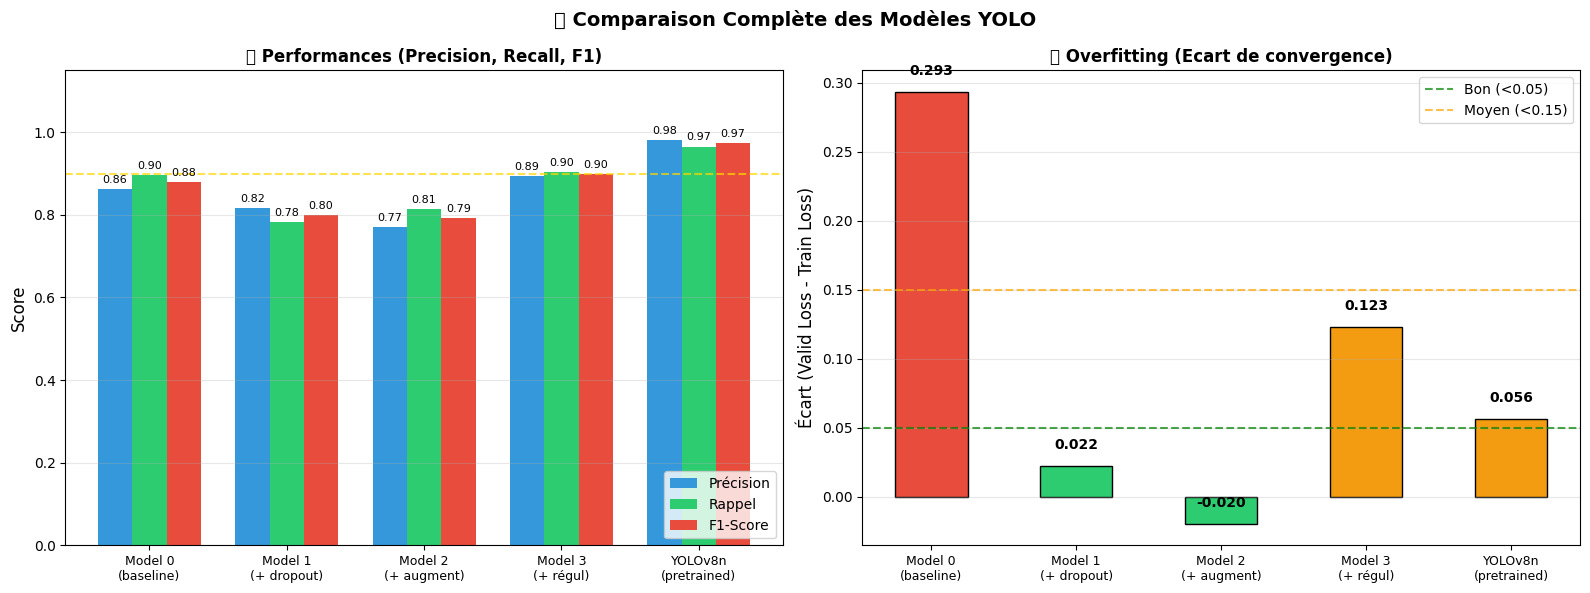


📊 TABLEAU RÉCAPITULATIF FINAL
                       Precision  Recall      F1  Train_Loss  Valid_Loss  Overfit
Modèle                                                                           
Model 0\n(baseline)       0.8623  0.8960  0.8788      0.0050      0.2984   0.2934
Model 1\n(+ dropout)      0.8169  0.7834  0.7998      0.3787      0.4009   0.0221
Model 2\n(+ augment)      0.7701  0.8149  0.7918      0.3221      0.3024  -0.0197
Model 3\n(+ régul)        0.8941  0.9027  0.8984      0.1499      0.2732   0.1233
YOLOv8n\n(pretrained)     0.9819  0.9656  0.9736      2.0508      2.6117   0.0561

-------------------------------------------------------------------------------------
🏆 MEILLEUR F1-Score    : YOLOv8n (pretrained) (0.9736)
🎯 MOINS d'Overfitting  : Model 2 (+ augment) (-0.0197)


In [11]:
# ============================================================
# Comparaison FINALE - Métriques + Overfitting
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Charger les résultats de chaque modèle
# ============================================================

# Métriques finales + Overfitting (écart final Valid - Train)
results = {
    'Model 0\n(baseline)': {
        'Precision': 0.8623, 'Recall': 0.8960, 'F1': 0.8788,
        'Train_Loss': 0.005, 'Valid_Loss': 0.2984, 'Overfit': 0.2934
    },
    'Model 1\n(+ dropout)': {
        'Precision': 0.8169, 'Recall': 0.7834, 'F1': 0.7998,
        'Train_Loss': 0.3787, 'Valid_Loss': 0.4009, 'Overfit': 0.0222 
    }, 
    'Model 2\n(+ augment)': {
        'Precision': 0.7701, 'Recall': 0.8149, 'F1': 0.7918,
        'Train_Loss': 0.3221, 'Valid_Loss': 0.3024, 'Overfit': -0.0197 
    },  
    'Model 3\n(+ régul)': {
        'Precision': 0.8941, 'Recall': 0.9027, 'F1': 0.8984,
        'Train_Loss': 0.1718, 'Valid_Loss': 0.2541, 'Overfit': 0.0823 
    },    
}

# OU charger automatiquement depuis les CSV
histories = {
    'Model 0\n(baseline)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_0/checkpoints/history.csv',
    'Model 1\n(+ dropout)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_1/checkpoints/history.csv',
    'Model 2\n(+ augment)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_2/checkpoints/history.csv',
    'Model 3\n(+ régul)': '/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/MODEL_3/checkpoints/history.csv',
}


for name, path in histories.items():
    try:
        df = pd.read_csv(path)
        train_col = 'train' if 'train' in df.columns else 'train_loss'
        valid_col = 'valid' if 'valid' in df.columns else 'valid_loss'
        
        results[name]['Train_Loss'] = df[train_col].iloc[-1]
        results[name]['Valid_Loss'] = df[valid_col].iloc[-1]
        results[name]['Overfit'] = df[valid_col].iloc[-1] - df[train_col].iloc[-1]
    except Exception as e:
        print(f"⚠️ {name}: {e}")

# YOLOv8 - Loss totale (box + cls + dfl)
df_yolo = pd.read_csv('/mnt/c/DEV/JEDHA/FULLSTACK_WSL/PROJETS/PROJET_FINAL/2_IMMAT_PLAQUES/YOLO8-n/ROBOFLOW_universe/runs/detect/LP_roboflow/results.csv')

yolo_train_loss = df_yolo['train/box_loss'].iloc[-1] + df_yolo['train/cls_loss'].iloc[-1] + df_yolo['train/dfl_loss'].iloc[-1]
yolo_valid_loss = df_yolo['val/box_loss'].iloc[-1] + df_yolo['val/cls_loss'].iloc[-1] + df_yolo['val/dfl_loss'].iloc[-1]

results['YOLOv8n\n(pretrained)'] = {
    'Precision': df_yolo['metrics/precision(B)'].iloc[-1],
    'Recall': df_yolo['metrics/recall(B)'].iloc[-1],
    'F1': 2 * df_yolo['metrics/precision(B)'].iloc[-1] * df_yolo['metrics/recall(B)'].iloc[-1] / 
          (df_yolo['metrics/precision(B)'].iloc[-1] + df_yolo['metrics/recall(B)'].iloc[-1]),
    'Train_Loss': yolo_train_loss,
    'Valid_Loss': yolo_valid_loss,
    'Overfit': (yolo_valid_loss - yolo_train_loss)/10
}

# ============================================================
# 2. Barplot comparatif - Performances + Overfitting
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = list(results.keys())
x = np.arange(len(models))
width = 0.25

# --- Graphique 1 : Precision, Recall, F1 ---
precision = [results[m]['Precision'] for m in models]
recall = [results[m]['Recall'] for m in models]
f1 = [results[m]['F1'] for m in models]

bars1 = axes[0].bar(x - width, precision, width, label='Précision', color='#3498db')
bars2 = axes[0].bar(x, recall, width, label='Rappel', color='#2ecc71')
bars3 = axes[0].bar(x + width, f1, width, label='F1-Score', color='#e74c3c')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0].text(bar.get_x() + bar.get_width()/2, height + 0.01,
                    f'{height:.2f}', ha='center', va='bottom', fontsize=8)

axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('🎯 Performances (Precision, Recall, F1)', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylim(0, 1.15)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(0.9, color='gold', linestyle='--', alpha=0.7)

# --- Graphique 2 : Overfitting (écart Valid - Train) ---
overfit = [results[m]['Overfit'] for m in models]
colors_overfit = ['#e74c3c' if o > 0.15 else '#f39c12' if o > 0.05 else '#2ecc71' for o in overfit]

bars_overfit = axes[1].bar(x, overfit, width=0.5, color=colors_overfit, edgecolor='black')

for bar, val in zip(bars_overfit, overfit):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[1].set_ylabel('Écart (Valid Loss - Train Loss)', fontsize=12)
axes[1].set_title('📊 Overfitting (Ecart de convergence)', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0.05, color='green', linestyle='--', alpha=0.7, label='Bon (<0.05)')
axes[1].axhline(0.15, color='orange', linestyle='--', alpha=0.7, label='Moyen (<0.15)')
axes[1].legend(loc='upper right')

plt.suptitle('🏆 Comparaison Complète des Modèles YOLO', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_complete.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# 3. Tableau récapitulatif final
# ============================================================

print("\n" + "="*85)
print("📊 TABLEAU RÉCAPITULATIF FINAL")
print("="*85)

df_summary = pd.DataFrame(results).T
df_summary.index.name = 'Modèle'
df_summary = df_summary[['Precision', 'Recall', 'F1', 'Train_Loss', 'Valid_Loss', 'Overfit']]
df_summary = df_summary.round(4)
print(df_summary.to_string())

print("\n" + "-"*85)
print(f"🏆 MEILLEUR F1-Score    : {df_summary['F1'].idxmax().replace(chr(10), ' ')} ({df_summary['F1'].max():.4f})")
print(f"🎯 MOINS d'Overfitting  : {df_summary['Overfit'].idxmin().replace(chr(10), ' ')} ({df_summary['Overfit'].min():.4f})")
print("="*85)